In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import(
    
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [25]:
df=pd.read_csv("dataset.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,30669,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,30468,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,16523,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,56543,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,46136,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0


In [26]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
43395,56196,Female,10.0,0,0,No,children,Urban,58.64,20.4,never smoked,0
43396,5450,Female,56.0,0,0,Yes,Govt_job,Urban,213.61,55.4,formerly smoked,0
43397,28375,Female,82.0,1,0,Yes,Private,Urban,91.94,28.9,formerly smoked,0
43398,27973,Male,40.0,0,0,Yes,Private,Urban,99.16,33.2,never smoked,0
43399,36271,Female,82.0,0,0,Yes,Private,Urban,79.48,20.6,never smoked,0


In [55]:
df.sample(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
17579,54381,Female,65.0,1,0,Yes,Private,Rural,186.30,27.4,formerly smoked,0
11355,6612,Female,35.0,0,0,Yes,Self-employed,Urban,84.21,20.1,never smoked,0
15707,5972,Female,80.0,0,0,Yes,Self-employed,Rural,93.89,26.5,never smoked,0
8880,28075,Male,22.0,0,0,No,Private,Urban,94.04,25.4,never smoked,0
32443,27606,Female,36.0,0,0,Yes,Private,Rural,71.72,26.1,never smoked,0


In [23]:
for cols in df.columns:
    print(f"\ncolun: {cols}")
    print(df[cols].unique())


colun: id
[30669 30468 16523 ... 28375 27973 36271]

colun: gender
<StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str

colun: age
[3.00e+00 5.80e+01 8.00e+00 7.00e+01 1.40e+01 4.70e+01 5.20e+01 7.50e+01
 3.20e+01 7.40e+01 7.90e+01 3.70e+01 4.00e+01 3.50e+01 2.00e+01 4.20e+01
 4.40e+01 6.50e+01 5.70e+01 4.90e+01 7.10e+01 5.90e+01 2.50e+01 6.70e+01
 3.80e+01 5.40e+01 2.70e+01 2.30e+01 5.50e+01 1.70e+01 1.30e+01 4.00e+00
 1.60e+01 2.20e+01 4.50e+01 6.60e+01 6.90e+01 5.30e+01 7.80e+01 4.30e+01
 5.10e+01 3.00e+01 4.60e+01 6.10e+01 4.80e+01 2.90e+01 1.10e+01 7.60e+01
 2.10e+01 1.80e+01 3.30e+01 8.20e+01 2.40e+01 3.40e+01 6.40e+01 6.80e+01
 6.00e+01 3.60e+01 3.90e+01 6.40e-01 7.20e+01 4.10e+01 5.60e+01 8.80e-01
 5.00e+00 8.00e+01 2.60e+01 3.10e+01 7.00e+00 1.20e+01 6.30e+01 6.20e+01
 2.00e+00 8.10e+01 9.00e+00 1.50e+01 2.80e+01 1.00e+01 7.70e+01 1.80e+00
 3.20e-01 1.08e+00 7.30e+01 5.00e+01 1.90e+01 6.00e+00 1.16e+00 1.00e+00
 1.40e+00 1.72e+00 2.40e-01 1.64e+00 1.56e+00 7.20e-0

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 43400 non-null  int64  
 1   gender             43400 non-null  str    
 2   age                43400 non-null  float64
 3   hypertension       43400 non-null  int64  
 4   heart_disease      43400 non-null  int64  
 5   ever_married       43400 non-null  str    
 6   work_type          43400 non-null  str    
 7   Residence_type     43400 non-null  str    
 8   avg_glucose_level  43400 non-null  float64
 9   bmi                41938 non-null  float64
 10  smoking_status     30108 non-null  str    
 11  stroke             43400 non-null  int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 4.0 MB


In [16]:
df.shape

(43400, 12)

In [24]:
df.duplicated().sum()

np.int64(0)

In [56]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')

In [63]:
df.drop("id",axis=1,inplace=True)

In [27]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,43400.000000,43400.000000,43400.000000,43400.000000,43400.000000,41938.000000,43400.000000
mean,36326.142350,42.217894,0.093571,0.047512,104.482750,28.605038,0.018041
std,21072.134879,22.519649,0.291235,0.212733,43.111751,7.770020,0.133103
min,1.000000,0.080000,0.000000,0.000000,55.000000,10.100000,0.000000
25%,18038.500000,24.000000,0.000000,0.000000,77.540000,23.200000,0.000000
50%,36351.500000,44.000000,0.000000,0.000000,91.580000,27.700000,0.000000
75%,54514.250000,60.000000,0.000000,0.000000,112.070000,32.900000,0.000000
max,72943.000000,82.000000,1.000000,1.000000,291.050000,97.600000,1.000000


In [60]:
df.isnull().sum()

id                       0
gender                   0
age                      0
hypertension             0
heart_disease            0
ever_married             0
work_type                0
Residence_type           0
avg_glucose_level        0
bmi                   1462
smoking_status       13292
stroke                   0
dtype: int64

In [64]:
numerical_col=df.select_dtypes(include="number").columns
catigorical_cols=df.select_dtypes(include=["object","string","category"]).columns

for cols in numerical_col:
    df[cols]=df[cols].fillna(df[cols].median())

for cols in catigorical_cols:
    df[cols]=df[cols].fillna(df[cols].mode()[0])

In [65]:
df.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [66]:
df.dtypes

gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

In [72]:
df["stroke"].unique()

array([0, 1])

{'whiskers': [<matplotlib.lines.Line2D at 0x14d1fbd9810>,
 'caps': [<matplotlib.lines.Line2D at 0x14d1fbd9a90>,
 'boxes': [<matplotlib.lines.Line2D at 0x14d1fb89a90>],
 'medians': [<matplotlib.lines.Line2D at 0x14d1fbd9bd0>],
 'fliers': [<matplotlib.lines.Line2D at 0x14d1fbd9d10>],
 'means': []}

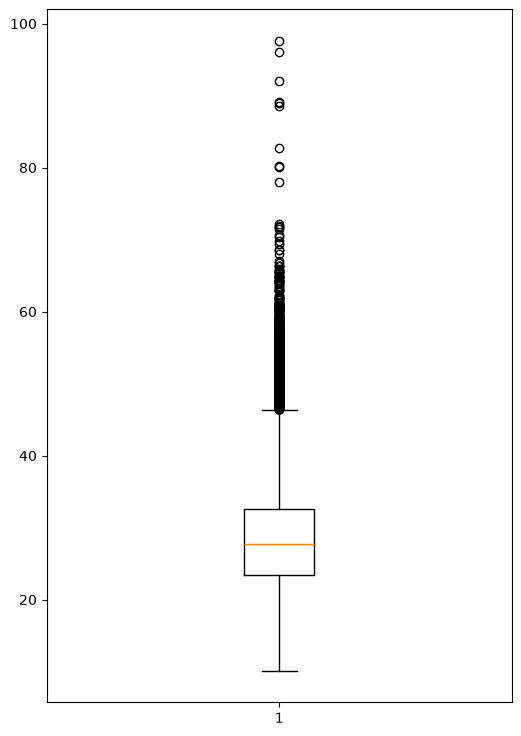

In [76]:
plt.figure(figsize=(6,9))

plt.boxplot(df["bmi"])


# encoded

In [93]:
cat_cols=df.select_dtypes(include="object").columns

C:\Users\Administrator\AppData\Local\Temp\ipykernel_20792\1520381097.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=df.select_dtypes(include="object").columns


In [94]:
df.head()# find unipe values for each columns
for col in cat_cols:
    print(col)
    print(df[col].unique())
    print("_"*40)

gender
<StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
________________________________________
Residence_type
<StringArray>
['Rural', 'Urban']
Length: 2, dtype: str
________________________________________
smoking_status
<StringArray>
['never smoked', 'formerly smoked', 'smokes']
Length: 3, dtype: str
________________________________________


In [83]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["ever_married"] = le.fit_transform(df["ever_married"])

In [95]:
df=df.replace({
    "Female":0,
    "Male":1,
    "Others":2
})

df=df.replace({
    "Urban":0,
    "Rural":1
})

df=df.replace({
    'never smoked':0,
    'smokes':1,
    'formerly smoked':2
})

# Feature selection

In [96]:
x=df.drop("stroke",axis=1)
y=df["stroke"]

## Train the model

In [97]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    train_size=0.2,
    random_state=42
)

# logisticregression